# BÀI TẬP 3 – HỆ ĐIỀU KHIỂN MỜ

## Bài toán 1: Thiết kế và mô phỏng hệ điều khiển máy giặt bằng logic mờ

Một hệ thống máy giặt thông minh sử dụng điều khiển logic mờ (Fuzzy Logic Control – FLC) để xác định thời gian giặt $T$ (phút) dựa trên hai biến đầu vào:
- Độ bẩn của quần áo ($D$): giá trị trong khoảng $[0,100]$
- Lượng dầu mỡ bám trên quần áo ($G$): giá trị trong khoảng $[0,100]$

Trong đó, giá trị càng lớn thì mức độ bẩn / dầu mỡ càng cao.

### Yêu cầu:

**1. Xác định biến và xây dựng tập mờ**
- Xác định: Không gian nền của các biến $D$, $G$ và $T$.
- Xây dựng tập mờ cho hai biến đầu vào $D$ và $G$, mỗi biến gồm 3 nhãn ngôn ngữ: *Ít – Vừa – Nhiều*
- Mô tả rõ: Miền giá trị, Dạng hàm thuộc (tam giác hoặc hình thang), Các tham số của từng hàm thuộc

**2. Xây dựng tập mờ cho biến đầu ra $T$**
- Đề xuất miền giá trị cho thời gian giặt $T: \left[0, 60 \right]$ phút
- Xây dựng 5 tập mờ cho $T$ với các nhãn: *Rất nhanh – Nhanh – Trung bình – Lâu – Rất lâu*
- Mô tả rõ: Dạng hàm thuộc, Ý nghĩa thực tế của từng mức thời gian

**3. Xây dựng hệ luật mờ**
- Thiết lập bảng luật mờ gồm 9 luật dạng: ```IF Độ bẩn là … AND Lượng dầu mỡ là … THEN Thời gian giặt là … ```
- Các luật cần phản ánh hợp lý kiến thức chuyên gia trong bài toán giặt quần áo.

**4. Suy diễn mờ với dữ liệu cụ thể**
- Với dữ liệu đầu vào: Độ bẩn: $D = 40$, Lượng dầu mỡ: $G = 60$
- Yêu cầu:
    + Tính mức độ thuộc của $D$ và $G$ vào các tập mờ tương ứng
    + Với từng luật mờ, xác định hệ số kích hoạt luật: $w_i = min(\mu_D,\mu_G)$
    + Trình bày rõ bảng suy diễn (rule firing strength)

**5. Ghép luật, giải mờ**
- Ghép các luật mờ để thu được hàm thuộc tổng hợp của biến đầu ra $\mu_T{t}$
- Giải mờ bằng phương pháp trọng tâm (Centroid method) để xác định thời gian giặt tối ưu $T^*$

**6. Lập trình minh họa bằng Python**
- Sử dụng numpy, matplotlib
- Khuyến khích dùng scikit-fuzzy
- Yêu cầu: Vẽ các hàm thuộc của $D$, $G$ và $T$; Thực hiện suy diễn mờ và giải mờ; In ra giá trị thời gian giặt cuối cùng

### Bài giải


**1. Xác định biến và xây dựng tập mờ**

- $D$ - Độ bẩn của quần áo. Miền giá trị của $D$ là $\left[0,100\right]$
- $G$ - Lượng dầu mở trên quần áo. Miền giá trị của $G$ là $\left[0,100\right]$
- $T$ - Thời gian giặt. Miền giá trị của $T$ là $\left[0,60\right]$

Viết **hàm thuộc liên tục** bằng nội suy tuyến tính qua các điểm đã cho. Kí hiệu công thức chung cho đường thẳng qua hai điểm $P(x_P,y_P)$, $Q(x_Q,y_Q)$:
$$
y(x)=y_P+(y_Q-y_P)\frac{x-x_P}{x_Q-x_P}.
$$

Không gian nền: $X= \left\{0,25,50,75,100 \right\}$

Xây dựng tập mờ cho biến đầu vào $D$
$$
D_{Ít} = 
\left\{
\frac{1}{0},
\frac{0.5}{25},
\frac{0}{50},
\frac{0}{75},
\frac{0}{100}
\right\}, \qquad

D_{Vừa} = 
\left\{
\frac{0}{0},
\frac{0.5}{25},
\frac{1}{50},
\frac{0.5}{75},
\frac{0}{100}
\right\}, \qquad

D_{Nhiều} = 
\left\{
\frac{0}{0},
\frac{0}{25},
\frac{0}{50},
\frac{0.5}{75},
\frac{1}{100}
\right\}
$$

Các mốc của $D_{Ít}$: $(0,1) \to (25,0.5) \to (50,0) \to (75,0) \to (100,0)$.

$$
\mu_{D_{Ít}}(d)=
\begin{cases}
1 + (0.5-1)\dfrac{x-0}{25-0}, & 0 \le x \lt 50, \\
0, & x\gt 50.
\end{cases}

\iff

\begin{cases}
1 - 0.5\dfrac{x}{25}, & 0 \le x \lt 50, \\
0, & x\gt 50.
\end{cases}

\iff

\begin{cases}
1 - \dfrac{x}{50}, & 0 \le x \le 50, \\
0, & x\gt 50.
\end{cases}
$$

Các mốc của $D_{Vừa}$: $(0,0) \to (25,0.5) \to (50,1) \to (75,0.5) \to (100,0)$.

$$
\mu_{D_{Vừa}}(d)=
\begin{cases}
0 + (1-0)\dfrac{x-0}{50-0}, & 0 \le x \le 50, \\
1 + (0-1)\dfrac{x-50}{100-50}, & 50 \lt x \le 100
\end{cases}

\iff

\begin{cases}
\dfrac{x}{25}, & 0 \le x \le 50, \\
1 - \dfrac{x-50}{50}, & 50 \lt x \le 100
\end{cases}

\iff

\begin{cases}
\dfrac{x}{25}, & 0 \le x \le 50, \\
2 - \dfrac{x}{50}, & 50 \lt x \le 100
\end{cases}
$$

Các mốc của $D_{Nhiều}$: $(0,0) \to (25,0) \to (50,0) \to (75,0.5) \to (100,1)$.

Xây dựng tập mờ cho biến đầu vào $G$

$$
G_{Ít} = 
\left\{
\frac{1}{0},
\frac{0.5}{25},
\frac{0}{50},
\frac{0}{75},
\frac{0}{100}
\right\}, \qquad

G_{Vừa} = 
\left\{
\frac{0}{0},
\frac{0.5}{25},
\frac{1}{50},
\frac{0.5}{75},
\frac{0}{100}
\right\}, \qquad

G_{Nhiều} = 
\left\{
\frac{0}{0},
\frac{0}{25},
\frac{0}{50},
\frac{0.5}{75},
\frac{1}{100}
\right\}

In [38]:
### Các thư viện cần thiết
import numpy as np
import skfuzzy as fz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

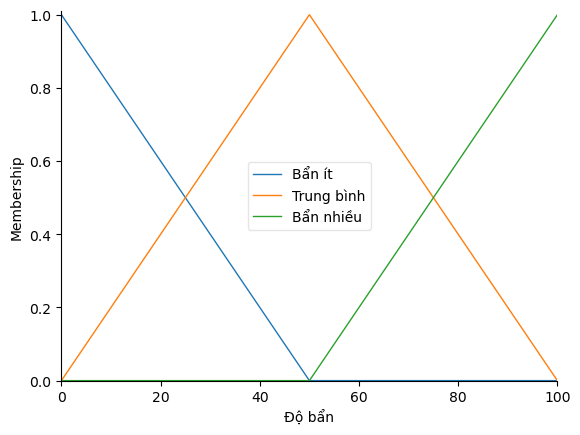

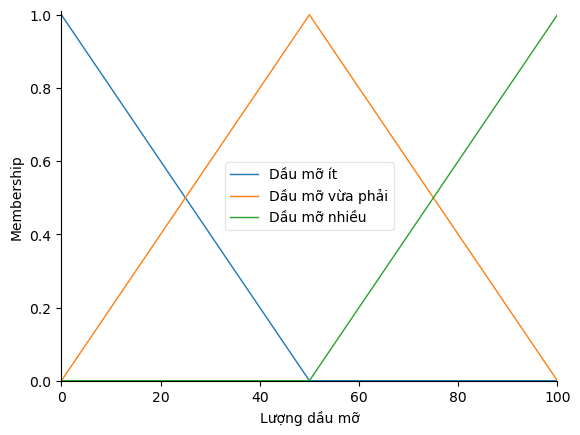

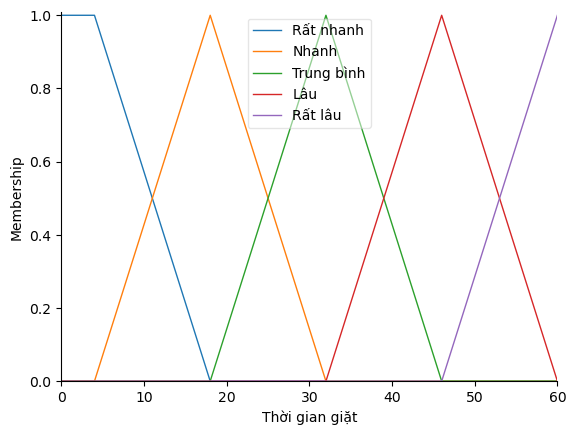

In [44]:
### Định nghĩa không gian nền (universe)
X = np.arange(0, 101, 1)
Y = X
Z = np.array([0,4,18,32,46,60])

### Xác định tiền đề và kết luận
D = ctrl.Antecedent(X, "Độ bẩn")            # Độ bẩn: 0..100
G = ctrl.Antecedent(Y, "Lượng dầu mỡ")      # Lượng dầu mỡ: 0..100
T = ctrl.Consequent(Z, "Thời gian giặt")    # Thời gian giặt: 0..60 phút

### Các tập mờ
D["Bẩn ít"] = fz.trimf(D.universe, [0, 0, 50])
D["Trung bình"] = fz.trimf(D.universe, [0, 50, 100])
D["Bẩn nhiều"] = fz.trimf(D.universe, [50, 100, 100])
D.view()

G["Dầu mỡ ít"] = fz.trimf(G.universe, [0, 0, 50])
G["Dầu mỡ vừa phải"] = fz.trimf(G.universe, [0, 50, 100])
G["Dầu mỡ nhiều"] = fz.trimf(G.universe, [50, 100, 100])
G.view()

T["Rất nhanh"] = fz.trapmf(T.universe, [0, 0, 4, 18])
T["Nhanh"] = fz.trimf(T.universe, [4, 18, 32])
T["Trung bình"] = fz.trimf(T.universe, [18, 32, 46])
T["Lâu"] = fz.trimf(T.universe, [32, 46, 60])
T["Rất lâu"] = fz.trimf(T.universe, [46, 60, 60])
T.view()

plt.show()

In [22]:
### Đưa các luật vào hệ thống
R1 = ctrl.Rule(D["Bẩn ít"] & G["Dầu mỡ ít"], T["Rất nhanh"])
R2 = ctrl.Rule(D["Bẩn ít"] & G["Dầu mỡ vừa phải"], T["Trung bình"])
R3 = ctrl.Rule(D["Bẩn ít"] & G["Dầu mỡ nhiều"], T["Lâu"])
R4 = ctrl.Rule(D["Trung bình"] & G["Dầu mỡ ít"], T["Nhanh"])
R5 = ctrl.Rule(D["Trung bình"] & G["Dầu mỡ vừa phải"], T["Trung bình"])
R6 = ctrl.Rule(D["Trung bình"] & G["Dầu mỡ nhiều"], T["Lâu"])
R7 = ctrl.Rule(D["Bẩn nhiều"] & G["Dầu mỡ ít"], T["Trung bình"])
R8 = ctrl.Rule(D["Bẩn nhiều"] & G["Dầu mỡ vừa phải"], T["Lâu"])
R9 = ctrl.Rule(D["Bẩn nhiều"] & G["Dầu mỡ nhiều"], T["Rất lâu"])

## Tạo mô hình để suy diễn
model = ctrl.ControlSystemSimulation(ctrl.ControlSystem([R1, R2, R3, R4, R5, R6, R7, R8, R9]))

In [ ]:
### Đưa dữ liệu vào mô hình để xử lý
B = float(input("Nhập độ bẩn của quần áo [0-100]: "))
C = float(input("Nhập lượng dầu mỡ trên quần áo [0-100]: "))

### Tính toán kết quả
model.input["Độ bẩn"] = B
model.input["Lượng dầu mỡ"] = C
model.compute()
D = model.output["Thời gian giặt"]

### Hiển thị kết quả
print("Với độ bẩn %.2f và %.2f lượng dầu mỡ trên quần áo, thời gian giặt là %2.f phút." % (B, C, D))


Với độ bẩn 40.00 và 60.00 lượng dầu mỡ trên quần áo, thời gian giặt là 36 phút.
